# Notebook 13 (V4_3) - Terminal-Tail Approximation Analysis

This notebook combines the former Notebook 13 horizon/buffer checks with the HKT-scalar tail diagnostic from Notebook 14. It keeps the model module untouched and installs notebook-local terminal closures only for this session.

The two experiments are:

1. **Horizon/buffer invariance.** Compare local-loglinear terminal-tail solutions across reported horizons and scratch buffers against the baseline `T_report = 45`, `n_buffer = 5` case.
2. **Terminal-rule sensitivity.** At each buffer, compare terminal successor rules against the same-buffer local-loglinear solution. The HKT scalar U.S.-dominant successor is treated as one terminal rule after certifying its tail prerequisites on the local-loglinear path.

Path plots show original level objects. Error tables and max-error plots use log differences for the six target observables:

$$
\log q_{US,t},\quad
\log(d/q)_{US,t},\quad
\log \varphi_{US,t},\quad
\log Q_{US,t},\quad
\log(-NFA_t),\quad
\log\left[\frac{q_t^b+d_t^b}{q_t^u}\left(\frac{C_t^u}{C_t^b}\right)^\gamma\right].
$$

Because U.S. NFA is negative on the target path, the notebook logs the deficit magnitude `-NFA_t` and records a domain failure if the sign condition fails. The theorem-ratio observable is `cond_1b`; its first stored entry is zero by construction, so log-error comparisons for this observable start at `t = 2`.


In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && return start_dir
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)
cd(PROJECT_DIR)

include(joinpath(PROJECT_DIR, "Two_country_production", "TwoCountryProductionOLG.jl"))

using Printf, Statistics, Markdown, LinearAlgebra
using Plots, LaTeXStrings
using Plots.PlotMeasures

gr()
default(size=(940, 560), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

const DEFAULT_OUTDIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                                "approximation_error_in_tails")
const OUTDIR = get(ENV, "TAIL_ANALYSIS_OUTDIR", DEFAULT_OUTDIR)
mkpath(OUTDIR)

const RUN_MODE = Symbol(get(ENV, "TAIL_ANALYSIS_MODE", "replication"))
@assert RUN_MODE in (:replication, :smoke) "RUN_MODE must be :replication or :smoke"

println("Project directory: ", PROJECT_DIR)
println("Output directory:  ", OUTDIR)
println("Run mode:          ", RUN_MODE)


  Activating 

Project directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails
Run mode:          replication


## 0. Calibration And Grids

Replication mode uses the agreed compact grid:

- Horizon/buffer grid: `T_report in {45, 60}`, `n_buffer in {0, 5, 20}`.
- Baseline reference: `T_report = 45`, `n_buffer = 5`, matching the certified `12_v9` common-growth run.
- Comparison windows: `T0 in {20, 30, 40}`.
- Terminal-rule sensitivity: `T_report = 45`, `n_buffer in {0, 5, 20}`.

Smoke mode keeps the same economic calibration but uses tiny horizons so the merged notebook can be checked quickly. Horizon/buffer invariance is deliberately local-loglinear only; terminal-rule sensitivity handles changes in the terminal closure.


In [2]:
const RESID_TOL = 1e-5

function tail_combo_params(; T_max::Int, n_buffer::Int)
    return ProductionParams(T_max=T_max,
        γ=0.25,
        π_persist=0.80,
        ξ_u=2.0,
        ν_u=1.5,
        ν_b=0.5,
        ξ_W=0.5,
        common_world_growth=true,
        branch_iters=100,
        n_buffer=n_buffer,
        do_global_polish=false)
end

if RUN_MODE == :smoke
    BASELINE_SPEC = (T_report=5, n_buffer=2)
    HORIZON_T_GRID = [5, 6]
    BUFFER_GRID = [0, 2]
    T0_GRID = [2, 4]
    TERMINAL_T_REPORT = 5
    TERMINAL_BUFFER_GRID = [0, 2]
    TAIL_REGRESSION_K_DEFAULT = 4
    HKT_PREREQ_TAIL_WINDOW = 3
else
    BASELINE_SPEC = (T_report=45, n_buffer=5)
    HORIZON_T_GRID = [45, 60]
    BUFFER_GRID = [0, 5, 20]
    T0_GRID = [20, 30, 40]
    TERMINAL_T_REPORT = 45
    TERMINAL_BUFFER_GRID = [0, 5, 20]
    TAIL_REGRESSION_K_DEFAULT = 8
    HKT_PREREQ_TAIL_WINDOW = 8
end

HORIZON_TERMINAL_RULE = :local_loglinear
TERMINAL_RULES = [:flat, :local_loglinear, :asymptotic_hkt, :tail_regression, :hkt_scalar_terminal_us]
TERMINAL_PLOT_BUFFER = BASELINE_SPEC.n_buffer in TERMINAL_BUFFER_GRID ? BASELINE_SPEC.n_buffer : first(TERMINAL_BUFFER_GRID)

println("Baseline spec: ", BASELINE_SPEC)
println("Horizon grid:  T_report=", HORIZON_T_GRID, ", n_buffer=", BUFFER_GRID)
println("T0 windows:    ", T0_GRID)
println("Terminal grid: T_report=", TERMINAL_T_REPORT, ", n_buffer=", TERMINAL_BUFFER_GRID)
println("Terminal rules: ", TERMINAL_RULES)
println("Terminal plot buffer: ", TERMINAL_PLOT_BUFFER)


Baseline spec: (T_report = 45, n_buffer = 5)
Horizon grid:  T_report=[45, 60], n_buffer=[0, 5, 20]
T0 windows:    [20, 30, 40]
Terminal grid: T_report=45, n_buffer=[0, 5, 20]
Terminal rules: [:flat, :local_loglinear, :asymptotic_hkt, :tail_regression, :hkt_scalar_terminal_us]
Terminal plot buffer: 5


## 1. Notebook-Local Terminal Closure Dispatcher

The production module is left untouched. After `include(...)`, this cell replaces `_extrapolate_terminal!` in the notebook session with a dispatcher over five terminal successor rules:

- `:flat`
- `:local_loglinear`
- `:asymptotic_hkt`
- `:tail_regression`
- `:hkt_scalar_terminal_us`

The HKT scalar rule writes only the artificial successor `varphi_{US,T_solve+1}`. The solved two-country path through `T_solve = T_report + n_buffer` is still computed from the full model.


In [3]:
const TAIL_TERMINAL_RULE = Ref(:local_loglinear)
const TAIL_TERMINAL_PARAMS = Ref{Any}(nothing)
const TAIL_REGRESSION_K = Ref(TAIL_REGRESSION_K_DEFAULT)

phi_clamp(x) = clamp(Float64(x), 1e-12, 1 - 1e-12)

function local_loglinear_phi(pol::Matrix{Float64}, i::Int, T::Int)
    if T >= 2
        a, b = pol[i, T - 1], pol[i, T]
        if isfinite(a) && isfinite(b) && a > 0 && b > 0
            return phi_clamp(b * b / a)
        end
    end
    return phi_clamp(pol[i, T])
end

function tail_regression_phi(pol::Matrix{Float64}, i::Int, T::Int; k::Int=8)
    lo = max(1, T - k + 1)
    idx = [t for t in lo:T if isfinite(pol[i, t]) && pol[i, t] > 0]
    length(idx) < 3 && return local_loglinear_phi(pol, i, T)

    x = Float64.(idx)
    y = log.([pol[i, t] for t in idx])
    xbar = mean(x); ybar = mean(y)
    sxx = sum(abs2, x .- xbar)
    sxx <= 0 && return local_loglinear_phi(pol, i, T)

    slope = sum((x .- xbar) .* (y .- ybar)) / sxx
    intercept = ybar - slope * xbar
    return phi_clamp(exp(intercept + slope * (T + 1)))
end

function asymptotic_hkt_phi_us(pol::Matrix{Float64}, T::Int)
    p = TAIL_TERMINAL_PARAMS[]
    p === nothing && return local_loglinear_phi(pol, 1, T)

    phi_T = phi_clamp(pol[1, T])
    psi_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
    asymptotic_rate = G_N_US(p, phi_T)^(-psi_US / p.ρ_US)
    if isfinite(asymptotic_rate) && asymptotic_rate > 0
        return phi_clamp(phi_T * asymptotic_rate)
    end
    return local_loglinear_phi(pol, 1, T)
end

function hkt_scalar_phi_us(p::ProductionParams, N_US::Real)
    aH = p.a_US * p.H_US
    B = (p.A_X_US_u * p.H_US * N_US^p.ξ_u) /
        (p.A_L_US_u * p.L_US * N_US^p.ν_u)
    c = (p.β * (1 - p.α_US)) / (p.ϑ_US * p.α_US)
    f(φ) = φ - 1 + p.β + c * B^(p.ρ_US - 1) * φ^p.ρ_US - 1 / aH

    f(1.0) <= 0 && return 1.0

    lo, hi = 1e-14, 1.0
    for _ in 1:240
        mid = 0.5 * (lo + hi)
        f(mid) > 0 ? (hi = mid) : (lo = mid)
    end
    return phi_clamp(0.5 * (lo + hi))
end

function hkt_scalar_successor_phi_us(pol::Matrix{Float64}, T::Int)
    p = TAIL_TERMINAL_PARAMS[]
    p === nothing && return local_loglinear_phi(pol, 1, T)

    # T is the extended solve horizon T_solve = T_report + n_buffer.
    # The scalar HKT equation is used only for the artificial successor.
    N_US_path = knowledge_path_US(p, vec(pol[1, 1:T]))
    N_US_succ = N_US_path[T + 1]
    return hkt_scalar_phi_us(p, N_US_succ)
end

function _extrapolate_terminal!(pol::Matrix{Float64}, T::Int)
    pol[:, T + 1] .= pol[:, T]
    rule = TAIL_TERMINAL_RULE[]

    if rule == :flat
        return pol
    elseif rule == :local_loglinear
        pol[1, T + 1] = local_loglinear_phi(pol, 1, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :asymptotic_hkt
        pol[1, T + 1] = asymptotic_hkt_phi_us(pol, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :tail_regression
        pol[1, T + 1] = tail_regression_phi(pol, 1, T; k=TAIL_REGRESSION_K[])
        pol[2, T + 1] = tail_regression_phi(pol, 2, T; k=TAIL_REGRESSION_K[])
    elseif rule == :hkt_scalar_terminal_us
        pol[1, T + 1] = hkt_scalar_successor_phi_us(pol, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    else
        error("Unknown terminal rule: $rule")
    end
    return pol
end

function set_terminal_rule!(rule::Symbol, p::ProductionParams)
    @assert rule in TERMINAL_RULES "unknown terminal rule"
    TAIL_TERMINAL_RULE[] = rule
    TAIL_TERMINAL_PARAMS[] = p
    return rule
end

println("Installed notebook-local terminal closure dispatcher.")


Installed notebook-local terminal closure dispatcher.


## 2. Helpers

Each solve returns the equilibrium path, the fundamental-value recursion, the NFA decomposition, a compact certification row, and any caught error. Results are cached by `(T_report, n_buffer, terminal_rule)`.

Error metrics are maximum absolute log differences. They do not floor bad domains. If a logged object is nonpositive or nonfinite over the comparison window, that metric is reported as missing and the row records a domain message.


In [4]:
path_vector(result, field::Symbol) = [getfield(s, field) for s in result.u_path]
path_vector_extended(result, field::Symbol) = [getfield(s, field) for s in result.u_path_extended]

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-4)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.6f", x)
        end
    end
    return string(x)
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    s = replace(s, "_" => "\\_")
    return s
end

function markdown_table(rows, cols; maxrows=length(rows))
    isempty(rows) && return Markdown.parse("_No rows._")
    io = IOBuffer()
    println(io, "| ", join([html_escape(c) for c in cols], " | "), " |")
    println(io, "| ", join(fill("---", length(cols)), " | "), " |")
    for r in rows[1:min(maxrows, length(rows))]
        println(io, "| ", join([html_escape(pretty(getproperty(r, Symbol(c)))) for c in cols], " | "), " |")
    end
    Markdown.parse(String(take!(io)))
end

function csv_escape(x)
    x === missing && return ""
    s = string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function write_csv(filename, rows, cols)
    open(filename, "w") do io
        println(io, join(cols, ","))
        for r in rows
            println(io, join([csv_escape(getproperty(r, Symbol(c))) for c in cols], ","))
        end
    end
    return filename
end

const RESULT_CACHE = Dict{Tuple{Int,Int,Symbol},Any}()

function run_tail_case(T_report::Int, n_buffer::Int, rule::Symbol; verbose::Bool=false)
    key = (T_report, n_buffer, rule)
    haskey(RESULT_CACHE, key) && return RESULT_CACHE[key]

    p = tail_combo_params(T_max=T_report, n_buffer=n_buffer)
    set_terminal_rule!(rule, p)
    @printf("Solving T=%d, buffer=%d, terminal=%s\n", T_report, n_buffer, String(rule))

    t0 = time()
    try
        result = run_production_simulation(p; verbose=verbose)
        fv = fundamental_value_path(result)
        nfa = nfa_decomposition(result)
        elapsed = time() - t0
        q = path_vector(result, :q_US)
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="ok",
            T_extended=length(result.u_path_extended),
            branch_converged=result.branch_converged,
            max_u_residual=result.max_u_residual,
            max_bgp_residual=result.max_bgp_residual,
            psi_ok=result.diagnostics.psi_ok,
            psi_min=result.diagnostics.psi_min,
            equity_weights_ok=result.diagnostics.equity_weights_ok,
            equity_weight_min=result.diagnostics.equity_weight_min,
            nu_b_effective=result.params.ν_b,
            q_growth=q[end] / q[1],
            minus_nfa_final=-nfa.NFA[end],
            cond_1b_final=result.diagnostics.cond_1b[end],
            bubble_share_final=fv.bubble_share[end],
            error="")
        out = (; status=:ok, result, fv, nfa, summary)
        RESULT_CACHE[key] = out
        return out
    catch err
        elapsed = time() - t0
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="error",
            T_extended=missing,
            branch_converged=missing,
            max_u_residual=missing,
            max_bgp_residual=missing,
            psi_ok=missing,
            psi_min=missing,
            equity_weights_ok=missing,
            equity_weight_min=missing,
            nu_b_effective=missing,
            q_growth=missing,
            minus_nfa_final=missing,
            cond_1b_final=missing,
            bubble_share_final=missing,
            error=sprint(showerror, err))
        out = (; status=:error, result=nothing, fv=nothing, nfa=nothing, summary)
        RESULT_CACHE[key] = out
        @warn "Solve failed" T_report n_buffer rule err
        return out
    end
end

function observable_paths(case)
    result = case.result
    T = length(result.u_path)
    q = Float64.(path_vector(result, :q_US))
    d = Float64.(path_vector(result, :d_US))
    phi = Float64.(path_vector(result, :φ_US))
    Q = Float64.(path_vector(result, :Q_US))
    cond_1b = Float64.(result.diagnostics.cond_1b[1:T])
    return (;
        q_US=q,
        d_over_q_US=d ./ q,
        phi_US=phi,
        Q_US=Q,
        minus_NFA=Float64.(-case.nfa.NFA),
        cond_1b=cond_1b)
end

ERROR_SPECS = [
    (; metric=:log_q_US, path=:q_US, start_t=1,
       max_col=:max_log_q_US_error, t_col=:t_max_log_q_US_error,
       plot_label=L"\log q_{US}"),
    (; metric=:log_d_over_q_US, path=:d_over_q_US, start_t=1,
       max_col=:max_log_d_over_q_US_error, t_col=:t_max_log_d_over_q_US_error,
       plot_label=L"\log(d/q)_{US}"),
    (; metric=:log_phi_US, path=:phi_US, start_t=1,
       max_col=:max_log_phi_US_error, t_col=:t_max_log_phi_US_error,
       plot_label=L"\log \varphi_{US}"),
    (; metric=:log_Q_US, path=:Q_US, start_t=1,
       max_col=:max_log_Q_US_error, t_col=:t_max_log_Q_US_error,
       plot_label=L"\log Q_{US}"),
    (; metric=:log_minus_NFA, path=:minus_NFA, start_t=1,
       max_col=:max_log_minus_NFA_error, t_col=:t_max_log_minus_NFA_error,
       plot_label=L"\log(-NFA)"),
    (; metric=:log_cond_1b, path=:cond_1b, start_t=2,
       max_col=:max_log_cond_1b_error, t_col=:t_max_log_cond_1b_error,
       plot_label=L"\log cond_{1b}")]

PATH_SPECS = [
    (; path=:q_US, start_t=1, title="q_US", ylabel=L"q_{US,t}"),
    (; path=:d_over_q_US, start_t=1, title="d_US / q_US", ylabel=L"(d/q)_{US,t}"),
    (; path=:phi_US, start_t=1, title="phi_US", ylabel=L"\varphi_{US,t}"),
    (; path=:Q_US, start_t=1, title="Q_US", ylabel=L"Q_{US,t}"),
    (; path=:minus_NFA, start_t=1, title="-NFA", ylabel=L"-NFA_t"),
    (; path=:cond_1b, start_t=2, title="cond_1b", ylabel=L"cond_{1b,t}")]

function missing_error_tuple(domain_status::String, domain_message::String)
    out = (;)
    for spec in ERROR_SPECS
        out = merge(out, NamedTuple{(spec.max_col, spec.t_col)}((missing, missing)))
    end
    return merge(out, (; log_cond_1b_start_t=2,
                       domain_status=domain_status,
                       domain_message=domain_message))
end

function max_log_error_for_values(case_values, ref_values, start_t::Int, T0::Int, label::String)
    T = min(T0, length(case_values), length(ref_values))
    if T < start_t
        return (value=missing, t=missing, status="empty_window",
                message="$label has no observations in t=$start_t:$T0")
    end

    idx = collect(start_t:T)
    cv = Float64.(case_values[idx])
    rv = Float64.(ref_values[idx])
    bad = findall(i -> !(isfinite(cv[i]) && isfinite(rv[i]) && cv[i] > 0 && rv[i] > 0), eachindex(idx))
    if !isempty(bad)
        b = bad[1]
        return (value=missing, t=idx[b], status="domain_failure",
                message=@sprintf("%s nonpositive/nonfinite at t=%d (case=%g, ref=%g)",
                                 label, idx[b], cv[b], rv[b]))
    end

    diffs = abs.(log.(cv) .- log.(rv))
    j = argmax(diffs)
    return (value=diffs[j], t=idx[j], status="ok", message="")
end

function comparison_metrics(case, ref, T0::Int)
    if case.status != :ok || ref.status != :ok
        return missing_error_tuple("case_error", "case or reference solve failed")
    end

    T = min(length(case.result.u_path), length(ref.result.u_path))
    if T0 > T
        return missing_error_tuple("window_error", "T0=$T0 exceeds available comparison length $T")
    end

    obs = observable_paths(case)
    obs_ref = observable_paths(ref)
    out = (;)
    messages = String[]
    for spec in ERROR_SPECS
        r = max_log_error_for_values(getproperty(obs, spec.path), getproperty(obs_ref, spec.path),
                                     spec.start_t, T0, String(spec.metric))
        out = merge(out, NamedTuple{(spec.max_col, spec.t_col)}((r.value, r.t)))
        r.status == "ok" || push!(messages, r.message)
    end

    domain_status = isempty(messages) ? "ok" : "domain_failure"
    return merge(out, (; log_cond_1b_start_t=2,
                       domain_status=domain_status,
                       domain_message=join(messages, " | ")))
end

function metric_column_names()
    cols = String[]
    for spec in ERROR_SPECS
        push!(cols, String(spec.max_col))
        push!(cols, String(spec.t_col))
    end
    push!(cols, "log_cond_1b_start_t", "domain_status", "domain_message")
    return cols
end

function plot_values(rows, col::Symbol)
    return [getproperty(r, col) === missing ? NaN : Float64(getproperty(r, col)) for r in rows]
end

function plot_error_grid(rows; title_prefix::String, filename::String, label_fn)
    isempty(rows) && return Markdown.parse("_No rows to plot._")
    labels = [label_fn(r) for r in rows]
    x = collect(1:length(rows))

    p1 = plot(title="$title_prefix: prices and policy", xlabel="case", ylabel="max abs log error",
              xticks=(x, labels), xrotation=35, legend=:topleft)
    for spec in ERROR_SPECS[1:3]
        plot!(p1, x, plot_values(rows, spec.max_col), marker=:circle, lw=2.1, label=spec.plot_label)
    end

    p2 = plot(title="$title_prefix: aggregates and theorem ratio", xlabel="case", ylabel="max abs log error",
              xticks=(x, labels), xrotation=35, legend=:topleft)
    for spec in ERROR_SPECS[4:6]
        plot!(p2, x, plot_values(rows, spec.max_col), marker=:square, lw=2.1, label=spec.plot_label)
    end

    fig = plot(p1, p2, layout=(2, 1), size=(1040, 820), bottom_margin=12mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

function plot_path_grid(cases; title_prefix::String, T0::Int, filename::String, label_fn)
    ok_cases = filter(c -> c.status == :ok, cases)
    isempty(ok_cases) && return Markdown.parse("_No successful cases to plot._")

    panels = Plots.Plot[]
    for spec in PATH_SPECS
        p = plot(title="$title_prefix: $(spec.title)", xlabel="period t", ylabel=spec.ylabel,
                 legend=:outerright)
        for c in ok_cases
            obs = observable_paths(c)
            vals = getproperty(obs, spec.path)
            T = min(T0, length(vals))
            T < spec.start_t && continue
            tt = spec.start_t:T
            plot!(p, tt, vals[tt], lw=2.0, label=label_fn(c))
        end
        push!(panels, p)
    end
    fig = plot(panels..., layout=(3, 2), size=(1180, 980), bottom_margin=8mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

function path_rows_for_cases(cases; experiment::String, T0::Int)
    rows = NamedTuple[]
    for c in cases
        c.status == :ok || continue
        obs = observable_paths(c)
        T = min(T0, length(obs.q_US))
        for t in 1:T
            push!(rows, (;
                experiment=experiment,
                T_report=c.summary.T_report,
                n_buffer=c.summary.n_buffer,
                terminal_rule=c.summary.terminal_rule,
                t=t,
                q_US=obs.q_US[t],
                d_over_q_US=obs.d_over_q_US[t],
                phi_US=obs.phi_US[t],
                Q_US=obs.Q_US[t],
                minus_NFA=obs.minus_NFA[t],
                cond_1b=obs.cond_1b[t]))
        end
    end
    return rows
end

case_label(c) = "T=$(c.summary.T_report), b=$(c.summary.n_buffer)"
rule_label(c) = c.summary.terminal_rule
row_case_label(r) = "T=$(r.T_report), b=$(r.n_buffer)"
row_rule_label(r) = r.terminal_rule

summary_cols = ["T_report", "n_buffer", "terminal_rule", "elapsed_sec", "status",
                "T_extended", "branch_converged", "max_u_residual", "max_bgp_residual",
                "psi_ok", "psi_min", "equity_weights_ok", "equity_weight_min",
                "nu_b_effective", "q_growth", "minus_nfa_final", "cond_1b_final",
                "bubble_share_final", "error"]

path_cols = ["experiment", "T_report", "n_buffer", "terminal_rule", "t",
             "q_US", "d_over_q_US", "phi_US", "Q_US", "minus_NFA", "cond_1b"]

println("Installed solve, metric, table, and plotting helpers.")


Installed solve, metric, table, and plotting helpers.


## 3. Horizon And Buffer Invariance

Every candidate here uses the local-loglinear terminal rule. The baseline reference is the `12_v9`-centered case `(T_report, n_buffer) = (45, 5)` in replication mode.


In [5]:
baseline_case = run_tail_case(BASELINE_SPEC.T_report, BASELINE_SPEC.n_buffer, HORIZON_TERMINAL_RULE)

horizon_cases = Any[]
for T_report in HORIZON_T_GRID, n_buffer in BUFFER_GRID
    push!(horizon_cases, run_tail_case(T_report, n_buffer, HORIZON_TERMINAL_RULE))
end

horizon_case_summary = [c.summary for c in horizon_cases]

horizon_rows = NamedTuple[]
for c in horizon_cases
    for T0 in T0_GRID
        m = comparison_metrics(c, baseline_case, T0)
        push!(horizon_rows, merge((;
            T_report=c.summary.T_report,
            n_buffer=c.summary.n_buffer,
            terminal_rule=c.summary.terminal_rule,
            baseline_T_report=BASELINE_SPEC.T_report,
            baseline_n_buffer=BASELINE_SPEC.n_buffer,
            T0=T0,
            status=c.summary.status,
            max_u_residual=c.summary.max_u_residual,
            max_bgp_residual=c.summary.max_bgp_residual), m))
    end
end

markdown_table(horizon_rows,
    ["T_report", "n_buffer", "T0", "status", "domain_status", "max_u_residual",
     "max_log_q_US_error", "max_log_d_over_q_US_error", "max_log_phi_US_error",
     "max_log_Q_US_error", "max_log_minus_NFA_error", "max_log_cond_1b_error"];
    maxrows=length(horizon_rows))


Solving T=45, buffer=5, terminal=local_loglinear
Solving T=45, buffer=0, terminal=local_loglinear
Solving T=45, buffer=20, terminal=local_loglinear
Solving T=60, buffer=0, terminal=local_loglinear
Solving T=60, buffer=5, terminal=local_loglinear
Solving T=60, buffer=20, terminal=local_loglinear


| T_report | n_buffer |  T0 | status |  domain_status | max_u_residual | max_log_q_US_error | max_log_d_over_q_US_error | max_log_phi_US_error | max_log_Q_US_error | max_log_minus_NFA_error | max_log_cond_1b_error |
| --------:| --------:| ---:| ------:| --------------:| --------------:| ------------------:| -------------------------:| --------------------:| ------------------:| -----------------------:| ---------------------:|
|       45 |        0 |  20 |     ok | domain_failure |       0.000147 |          4.159e-06 |                 2.229e-06 |            2.229e-06 |          5.205e-06 |                         |             4.022e-06 |
|       45 |        0 |  30 |     ok | domain_failure |       0.000147 |          3.295e-05 |                 1.738e-05 |            1.738e-05 |          4.158e-05 |                         |             3.309e-05 |
|       45 |        0 |  40 |     ok | domain_failure |       0.000147 |           0.000129 |                 6.700e-05 |            6.700e-05 |           0.000165 |                         |              0.000131 |
|       45 |        5 |  20 |     ok | domain_failure |      8.512e-06 |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        5 |  30 |     ok | domain_failure |      8.512e-06 |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        5 |  40 |     ok | domain_failure |      8.512e-06 |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |       20 |  20 |     ok | domain_failure |      2.810e-06 |          7.402e-05 |                 3.968e-05 |            3.968e-05 |          9.246e-05 |                         |             7.111e-05 |
|       45 |       20 |  30 |     ok | domain_failure |      2.810e-06 |           0.000598 |                  0.000316 |             0.000316 |           0.000753 |                         |              0.000595 |
|       45 |       20 |  40 |     ok | domain_failure |      2.810e-06 |           0.002357 |                  0.001227 |             0.001227 |           0.003010 |                         |              0.002364 |
|       60 |        0 |  20 |     ok | domain_failure |       0.001168 |          5.976e-05 |                 3.204e-05 |            3.204e-05 |          7.465e-05 |                         |             5.742e-05 |
|       60 |        0 |  30 |     ok | domain_failure |       0.001168 |           0.000483 |                  0.000255 |             0.000255 |           0.000608 |                         |              0.000480 |
|       60 |        0 |  40 |     ok | domain_failure |       0.001168 |           0.001904 |                  0.000991 |             0.000991 |           0.002431 |                         |              0.001910 |
|       60 |        5 |  20 |     ok | domain_failure |      6.569e-06 |          7.402e-05 |                 3.968e-05 |            3.968e-05 |          9.246e-05 |                         |             7.111e-05 |
|       60 |        5 |  30 |     ok | domain_failure |      6.569e-06 |           0.000598 |                  0.000316 |             0.000316 |           0.000753 |                         |              0.000595 |
|       60 |        5 |  40 |     ok | domain_failure |      6.569e-06 |           0.002357 |                  0.001227 |             0.001227 |           0.003010 |                         |              0.002364 |
|       60 |       20 |  20 |     ok | domain_failure |      1.267e-09 |          5.387e-05 |                 2.888e-05 |            2.888e-05 |          6.731e-05 |                         |             5.182e-05 |
|       60 |       20 |  30 |     ok | domain_failure |      1.267e-09 |           0.000434 |                  0.000229 |             0.000229 |           0.000547 |                         |              0.000433 |
|       60 |       20 |  40 |     ok | domain_failure |      1.267e-09 |           0.001713 |                  0.000892 |             0.000892 |           0.002188 |                         |              0.001725 |


In [6]:
horizon_metric_cols = vcat(["T_report", "n_buffer", "terminal_rule", "baseline_T_report",
                            "baseline_n_buffer", "T0", "status", "max_u_residual",
                            "max_bgp_residual"], metric_column_names())

horizon_path_rows = path_rows_for_cases(horizon_cases; experiment="horizon_buffer", T0=maximum(T0_GRID))

write_csv(joinpath(OUTDIR, "horizon_buffer_case_summary.csv"), horizon_case_summary, summary_cols)
write_csv(joinpath(OUTDIR, "horizon_buffer_invariance.csv"), horizon_rows, horizon_metric_cols)
write_csv(joinpath(OUTDIR, "horizon_buffer_paths.csv"), horizon_path_rows, path_cols)
println("Saved horizon/buffer tables to ", OUTDIR)


Saved horizon/buffer tables to /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails


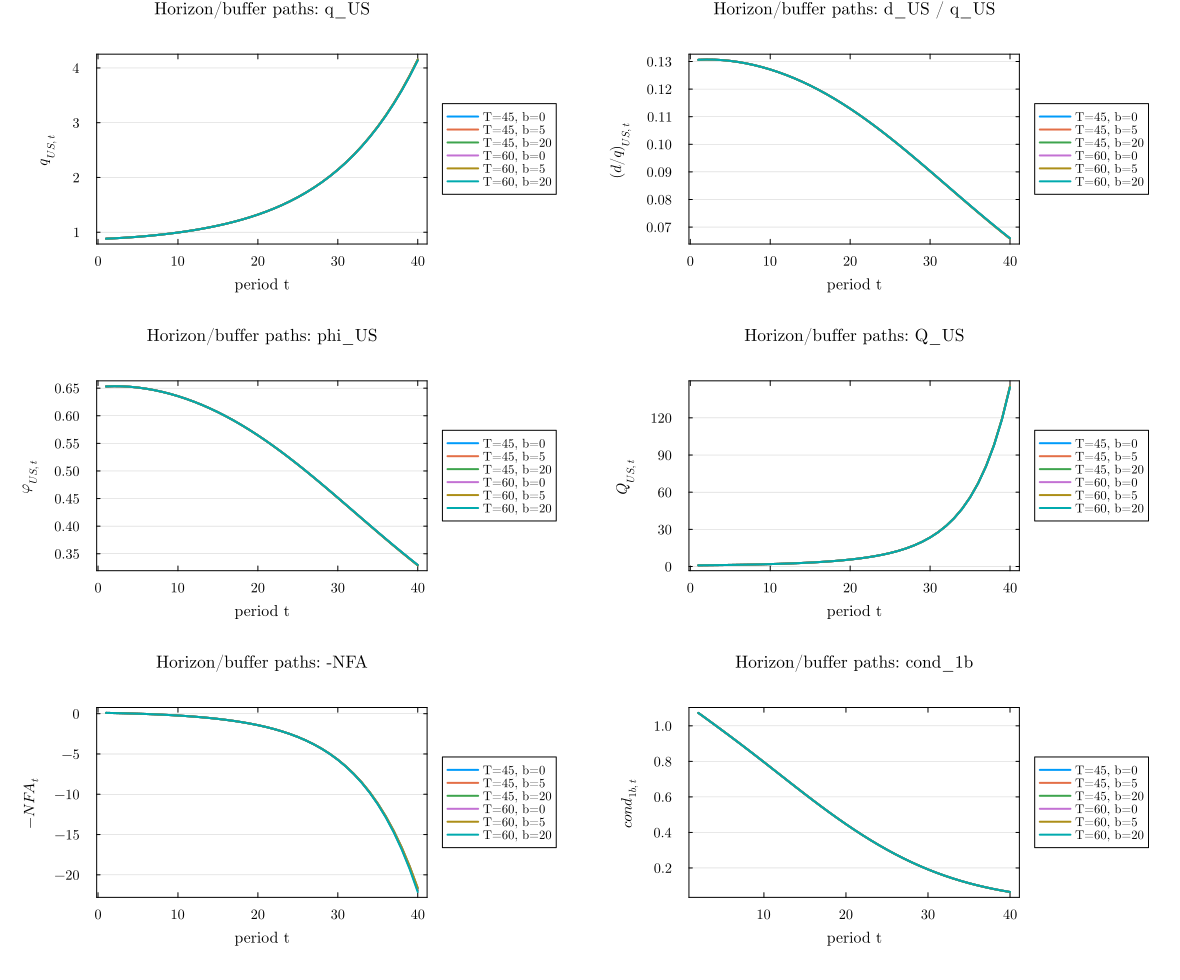

In [7]:
fig_horizon_paths = plot_path_grid(horizon_cases;
    title_prefix="Horizon/buffer paths",
    T0=maximum(T0_GRID),
    filename="horizon_buffer_paths.png",
    label_fn=case_label)
fig_horizon_paths


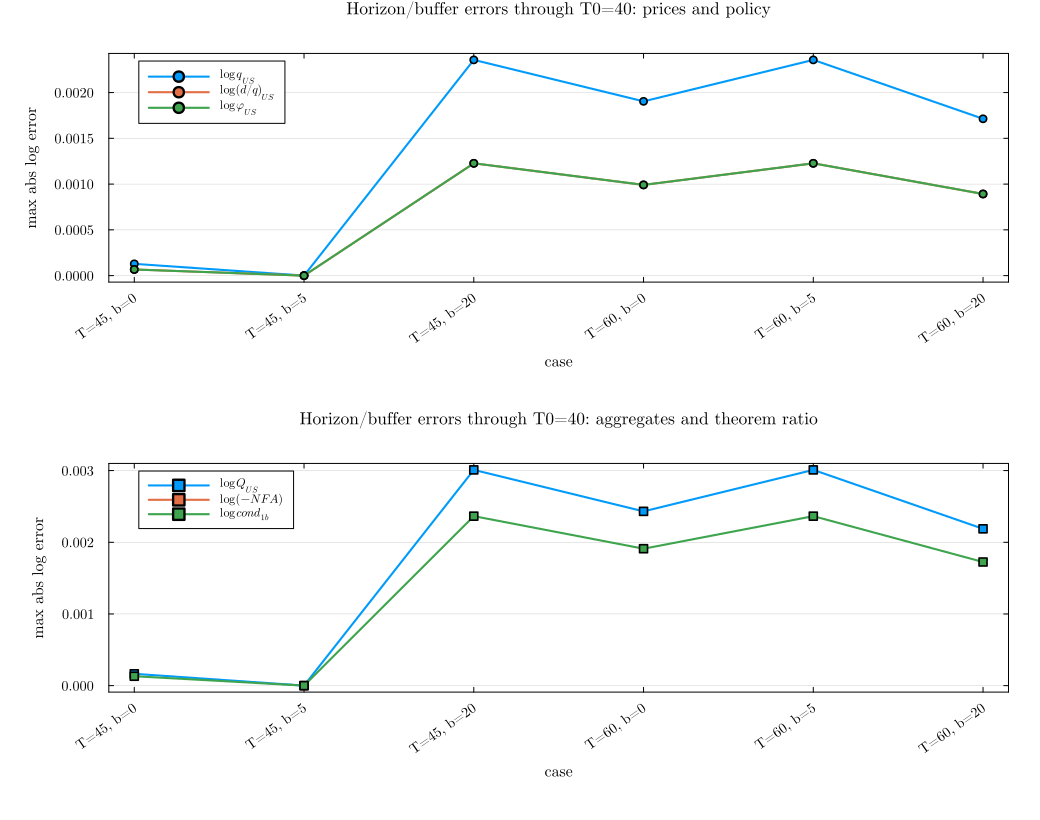

In [8]:
plot_T0 = maximum(T0_GRID)
hrows_plot = filter(r -> r.T0 == plot_T0 && r.status == "ok", horizon_rows)
fig_horizon_errors = plot_error_grid(hrows_plot;
    title_prefix="Horizon/buffer errors through T0=$plot_T0",
    filename="horizon_buffer_invariance_errors.png",
    label_fn=row_case_label)
fig_horizon_errors


## 4. HKT Scalar Prerequisite Certification

Before using the HKT scalar U.S.-dominant successor as a terminal rule, certify its prerequisite tail limits on the **local-loglinear** solved path only:

$$
\boxed{
\frac{e_W}{e_{US}}\to0,
\qquad
\frac{Q_W}{Q_{US}}\to0,
\qquad
\omega_t(1-\theta_t)\to1,
\qquad
\omega_t^*\frac{S_t^*}{\beta e_{US,t}}\to0.
}
$$

The table reports the last `HKT_PREREQ_TAIL_WINDOW` periods of the extended solved path for each terminal buffer. The compact summary records the final value and the worst last-window deviation from the target.


In [9]:
function hkt_prerequisite_tail_rows(case; last_k::Int=8)
    case.status == :ok || return NamedTuple[]
    result = case.result
    u = result.u_path_extended
    T_report = length(result.u_path)
    T_ext = length(u)
    lo = max(1, T_ext - last_k + 1)
    rows = NamedTuple[]
    for i in lo:T_ext
        s = u[i]
        push!(rows, (;
            T_report=T_report,
            n_buffer=T_ext - T_report,
            terminal_rule=case.summary.terminal_rule,
            solved_t=i,
            is_reported_period=i <= T_report,
            periods_to_extended_end=T_ext - i,
            e_W_over_e_US=s.e_W / s.e_US,
            Q_W_over_Q_US=s.Q_W / s.Q_US,
            omega_times_one_minus_theta=s.ω * (1 - s.θ),
            omega_star_S_star_over_beta_e_US=s.ω_star * s.S_star / (result.params.β * s.e_US),
            omega_US=s.ω,
            theta_US=s.θ,
            omega_star=s.ω_star,
            S_star_over_beta_e_US=s.S_star / (result.params.β * s.e_US),
            phi_US=s.φ_US,
            phi_W=s.φ_W,
            q_US=s.q_US,
            q_W=s.q_W,
            residual_norm=s.residual_norm))
    end
    return rows
end

function hkt_prerequisite_summary(case; last_k::Int=8)
    if case.status != :ok
        return (T_report=case.summary.T_report, n_buffer=case.summary.n_buffer,
                terminal_rule=case.summary.terminal_rule, status=case.summary.status,
                tail_window=last_k, final_solved_t=missing,
                final_e_W_over_e_US=missing, max_tail_e_W_over_e_US=missing,
                final_Q_W_over_Q_US=missing, max_tail_Q_W_over_Q_US=missing,
                final_omega_times_one_minus_theta=missing,
                max_tail_abs_omega_times_one_minus_theta_minus_1=missing,
                final_omega_star_S_star_over_beta_e_US=missing,
                max_tail_omega_star_S_star_over_beta_e_US=missing,
                max_tail_residual_norm=missing)
    end

    rows = hkt_prerequisite_tail_rows(case; last_k=last_k)
    final = rows[end]
    omega_dev = [abs(r.omega_times_one_minus_theta - 1) for r in rows]
    return (;
        T_report=case.summary.T_report,
        n_buffer=case.summary.n_buffer,
        terminal_rule=case.summary.terminal_rule,
        status=case.summary.status,
        tail_window=last_k,
        final_solved_t=final.solved_t,
        final_e_W_over_e_US=final.e_W_over_e_US,
        max_tail_e_W_over_e_US=maximum(r.e_W_over_e_US for r in rows),
        final_Q_W_over_Q_US=final.Q_W_over_Q_US,
        max_tail_Q_W_over_Q_US=maximum(r.Q_W_over_Q_US for r in rows),
        final_omega_times_one_minus_theta=final.omega_times_one_minus_theta,
        max_tail_abs_omega_times_one_minus_theta_minus_1=maximum(omega_dev),
        final_omega_star_S_star_over_beta_e_US=final.omega_star_S_star_over_beta_e_US,
        max_tail_omega_star_S_star_over_beta_e_US=maximum(r.omega_star_S_star_over_beta_e_US for r in rows),
        max_tail_residual_norm=maximum(r.residual_norm for r in rows))
end

function plot_hkt_prerequisites(cases; filename::String)
    ok_cases = filter(c -> c.status == :ok, cases)
    isempty(ok_cases) && return Markdown.parse("_No successful local-loglinear cases to plot._")

    p_e = plot(title="HKT prerequisite: e_W/e_US", xlabel="solved period", ylabel=L"e_W/e_{US}", legend=:outerright)
    p_Q = plot(title="HKT prerequisite: Q_W/Q_US", xlabel="solved period", ylabel=L"Q_W/Q_{US}", legend=:outerright)
    p_w = plot(title="HKT prerequisite: omega*(1-theta)", xlabel="solved period", ylabel=L"\omega_t(1-\theta_t)", legend=:outerright)
    p_s = plot(title="HKT prerequisite: RoW US-claim share", xlabel="solved period", ylabel=L"\omega_t^* S_t^*/(\beta e_{US,t})", legend=:outerright)

    for c in ok_cases
        u = c.result.u_path_extended
        tt = 1:length(u)
        label = "b=$(c.summary.n_buffer)"
        plot!(p_e, tt, [s.e_W / s.e_US for s in u], lw=2.0, label=label)
        plot!(p_Q, tt, [s.Q_W / s.Q_US for s in u], lw=2.0, label=label)
        plot!(p_w, tt, [s.ω * (1 - s.θ) for s in u], lw=2.0, label=label)
        plot!(p_s, tt, [s.ω_star * s.S_star / (c.result.params.β * s.e_US) for s in u], lw=2.0, label=label)
    end
    hline!(p_w, [1.0], lc=:black, ls=:dash, lw=1.0, label="target")
    hline!(p_e, [0.0], lc=:black, ls=:dash, lw=1.0, label="target")
    hline!(p_Q, [0.0], lc=:black, ls=:dash, lw=1.0, label="target")
    hline!(p_s, [0.0], lc=:black, ls=:dash, lw=1.0, label="target")

    fig = plot(p_e, p_Q, p_w, p_s, layout=(2, 2), size=(1120, 760), bottom_margin=7mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

hkt_prereq_cases = [run_tail_case(TERMINAL_T_REPORT, n_buffer, :local_loglinear)
                    for n_buffer in TERMINAL_BUFFER_GRID]

hkt_prereq_tail_rows = reduce(vcat,
    [hkt_prerequisite_tail_rows(c; last_k=HKT_PREREQ_TAIL_WINDOW) for c in hkt_prereq_cases];
    init=NamedTuple[])

hkt_prereq_summary_rows = [hkt_prerequisite_summary(c; last_k=HKT_PREREQ_TAIL_WINDOW)
                           for c in hkt_prereq_cases]

hkt_prereq_tail_cols = ["T_report", "n_buffer", "terminal_rule", "solved_t", "is_reported_period",
                        "periods_to_extended_end", "e_W_over_e_US", "Q_W_over_Q_US",
                        "omega_times_one_minus_theta", "omega_star_S_star_over_beta_e_US",
                        "omega_US", "theta_US", "omega_star", "S_star_over_beta_e_US",
                        "phi_US", "phi_W", "q_US", "q_W", "residual_norm"]

hkt_prereq_summary_cols = ["T_report", "n_buffer", "terminal_rule", "status", "tail_window",
                           "final_solved_t", "final_e_W_over_e_US", "max_tail_e_W_over_e_US",
                           "final_Q_W_over_Q_US", "max_tail_Q_W_over_Q_US",
                           "final_omega_times_one_minus_theta",
                           "max_tail_abs_omega_times_one_minus_theta_minus_1",
                           "final_omega_star_S_star_over_beta_e_US",
                           "max_tail_omega_star_S_star_over_beta_e_US",
                           "max_tail_residual_norm"]

write_csv(joinpath(OUTDIR, "hkt_scalar_prerequisite_tail_rows.csv"), hkt_prereq_tail_rows, hkt_prereq_tail_cols)
write_csv(joinpath(OUTDIR, "hkt_scalar_prerequisite_summary.csv"), hkt_prereq_summary_rows, hkt_prereq_summary_cols)

markdown_table(hkt_prereq_summary_rows,
    ["T_report", "n_buffer", "tail_window", "final_e_W_over_e_US",
     "final_Q_W_over_Q_US", "final_omega_times_one_minus_theta",
     "final_omega_star_S_star_over_beta_e_US", "max_tail_residual_norm"];
    maxrows=length(hkt_prereq_summary_rows))


| T_report | n_buffer | tail_window | final_e_W_over_e_US | final_Q_W_over_Q_US | final_omega_times_one_minus_theta | final_omega_star_S_star_over_beta_e_US | max_tail_residual_norm |
| --------:| --------:| -----------:| -------------------:| -------------------:| ---------------------------------:| --------------------------------------:| ----------------------:|
|       45 |        0 |           8 |            0.019469 |            0.127580 |                          0.896644 |                               0.007561 |               0.000147 |
|       45 |        5 |           8 |            0.010746 |            0.081932 |                          0.929444 |                               0.004804 |               0.000666 |
|       45 |       20 |           8 |            0.001571 |            0.015775 |                          0.985099 |                               0.000922 |               0.001438 |


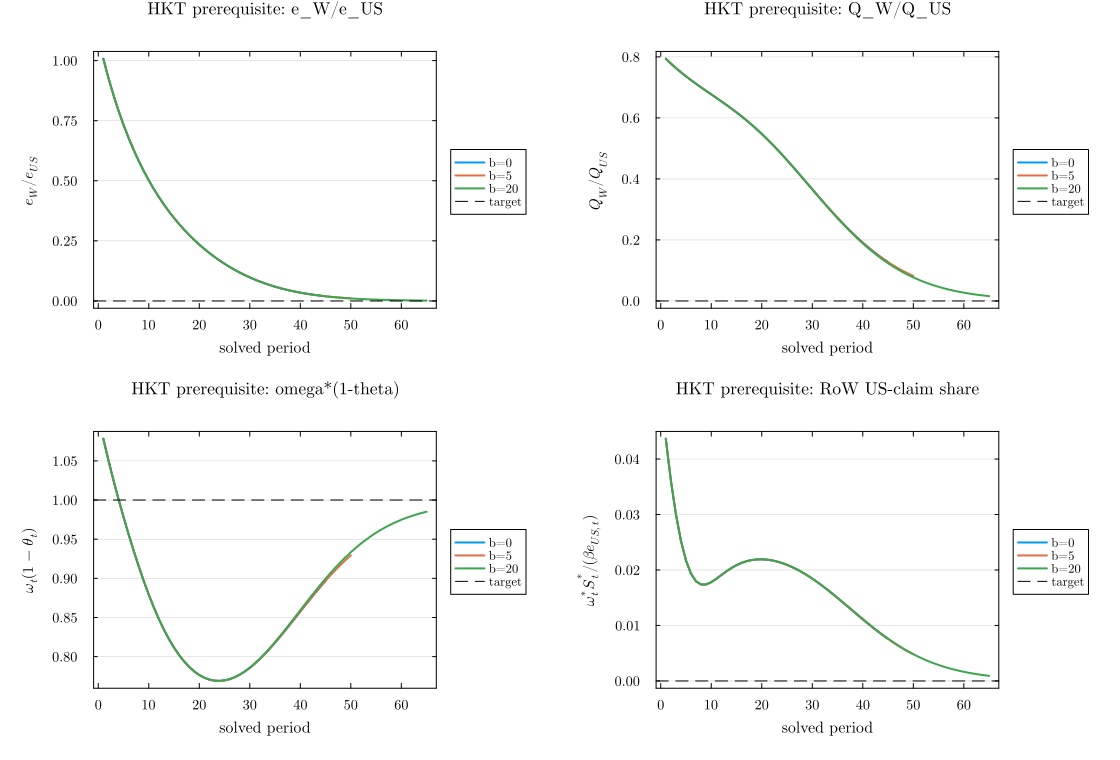

In [10]:
fig_hkt_prereq = plot_hkt_prerequisites(hkt_prereq_cases;
    filename="hkt_scalar_prerequisite_diagnostics.png")
fig_hkt_prereq


## 5. Terminal-Rule Sensitivity

For each buffer, every terminal rule is compared against the same-buffer local-loglinear solution. The HKT scalar U.S.-dominant successor is included as a terminal rule, while its prerequisite certification remains based only on the local-loglinear path above.

Path plots are generated only for the baseline buffer. Tables and CSVs cover every buffer in `TERMINAL_BUFFER_GRID`.


In [11]:
terminal_cases = Any[]
for n_buffer in TERMINAL_BUFFER_GRID, rule in TERMINAL_RULES
    push!(terminal_cases, run_tail_case(TERMINAL_T_REPORT, n_buffer, rule))
end

terminal_case_summary = [c.summary for c in terminal_cases]

terminal_rows = NamedTuple[]
for n_buffer in TERMINAL_BUFFER_GRID
    ref = run_tail_case(TERMINAL_T_REPORT, n_buffer, :local_loglinear)
    for rule in TERMINAL_RULES
        c = run_tail_case(TERMINAL_T_REPORT, n_buffer, rule)
        for T0 in T0_GRID
            m = comparison_metrics(c, ref, T0)
            push!(terminal_rows, merge((;
                T_report=TERMINAL_T_REPORT,
                n_buffer=n_buffer,
                terminal_rule=String(rule),
                reference_rule="local_loglinear",
                T0=T0,
                status=c.summary.status,
                max_u_residual=c.summary.max_u_residual,
                max_bgp_residual=c.summary.max_bgp_residual), m))
        end
    end
end

markdown_table(terminal_rows,
    ["T_report", "n_buffer", "terminal_rule", "T0", "status", "domain_status",
     "max_log_q_US_error", "max_log_d_over_q_US_error", "max_log_phi_US_error",
     "max_log_Q_US_error", "max_log_minus_NFA_error", "max_log_cond_1b_error"];
    maxrows=length(terminal_rows))


Solving T=45, buffer=0, terminal=flat
Solving T=45, buffer=0, terminal=asymptotic_hkt
Solving T=45, buffer=0, terminal=tail_regression
Solving T=45, buffer=0, terminal=hkt_scalar_terminal_us
Solving T=45, buffer=5, terminal=flat
Solving T=45, buffer=5, terminal=asymptotic_hkt
Solving T=45, buffer=5, terminal=tail_regression
Solving T=45, buffer=5, terminal=hkt_scalar_terminal_us
Solving T=45, buffer=20, terminal=flat
Solving T=45, buffer=20, terminal=asymptotic_hkt
Solving T=45, buffer=20, terminal=tail_regression
Solving T=45, buffer=20, terminal=hkt_scalar_terminal_us


| T_report | n_buffer |          terminal_rule |  T0 | status |  domain_status | max_log_q_US_error | max_log_d_over_q_US_error | max_log_phi_US_error | max_log_Q_US_error | max_log_minus_NFA_error | max_log_cond_1b_error |
| --------:| --------:| ----------------------:| ---:| ------:| --------------:| ------------------:| -------------------------:| --------------------:| ------------------:| -----------------------:| ---------------------:|
|       45 |        0 |                   flat |  20 |     ok | domain_failure |           0.000407 |                  0.000218 |             0.000218 |           0.000508 |                         |              0.000391 |
|       45 |        0 |                   flat |  30 |     ok | domain_failure |           0.003291 |                  0.001737 |             0.001737 |           0.004146 |                         |              0.003278 |
|       45 |        0 |                   flat |  40 |     ok | domain_failure |           0.013165 |                  0.006854 |             0.006854 |           0.016788 |                         |              0.013246 |
|       45 |        0 |        local_loglinear |  20 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        0 |        local_loglinear |  30 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        0 |        local_loglinear |  40 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        0 |         asymptotic_hkt |  20 |     ok | domain_failure |           0.000407 |                  0.000218 |             0.000218 |           0.000509 |                         |              0.000392 |
|       45 |        0 |         asymptotic_hkt |  30 |     ok | domain_failure |           0.003293 |                  0.001737 |             0.001737 |           0.004149 |                         |              0.003281 |
|       45 |        0 |         asymptotic_hkt |  40 |     ok | domain_failure |           0.013168 |                  0.006855 |             0.006855 |           0.016792 |                         |              0.013255 |
|       45 |        0 |        tail_regression |  20 |     ok | domain_failure |          1.378e-05 |                 7.385e-06 |            7.385e-06 |          1.722e-05 |                         |             1.326e-05 |
|       45 |        0 |        tail_regression |  30 |     ok | domain_failure |           0.000111 |                 5.841e-05 |            5.841e-05 |           0.000140 |                         |              0.000110 |
|       45 |        0 |        tail_regression |  40 |     ok | domain_failure |           0.000436 |                  0.000227 |             0.000227 |           0.000557 |                         |              0.000440 |
|       45 |        0 | hkt_scalar_terminal_us |  20 |     ok | domain_failure |           0.001725 |                  0.000925 |             0.000925 |           0.002154 |                         |              0.001657 |
|       45 |        0 | hkt_scalar_terminal_us |  30 |     ok | domain_failure |           0.013792 |                  0.007277 |             0.007277 |           0.017388 |                         |              0.013714 |
|       45 |        0 | hkt_scalar_terminal_us |  40 |     ok | domain_failure |           0.051477 |                  0.026797 |             0.026797 |           0.066135 |                         |              0.051345 |
|       45 |        5 |                   flat |  20 |     ok | domain_failure |           0.000240 |                  0.000129 |             0.000129 |           0.000300 |                         |              0.000231 |
|       45 |        5 |                   flat |  30 |     ok | domain_failure |           0.001943 |                  0.001025 |             0.001025 |           0.002448 |                         |              0.001935 |
|       45 |        5 |                   flat |  40 |     ok | domain_failure |           0.007727 |                  0.004022 |             0.004022 |           0.009859 |                         |              0.007772 |
|       45 |        5 |        local_loglinear |  20 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        5 |        local_loglinear |  30 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        5 |        local_loglinear |  40 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |        5 |         asymptotic_hkt |  20 |     ok | domain_failure |           0.000168 |                 9.021e-05 |            9.021e-05 |           0.000210 |                         |              0.000162 |
|       45 |        5 |         asymptotic_hkt |  30 |     ok | domain_failure |           0.001358 |                  0.000717 |             0.000717 |           0.001712 |                         |              0.001353 |
|       45 |        5 |         asymptotic_hkt |  40 |     ok | domain_failure |           0.005388 |                  0.002805 |             0.002805 |           0.006877 |                         |              0.005420 |
|       45 |        5 |        tail_regression |  20 |     ok | domain_failure |          5.188e-05 |                 2.782e-05 |            2.782e-05 |          6.480e-05 |                         |             4.982e-05 |
|       45 |        5 |        tail_regression |  30 |     ok | domain_failure |           0.000420 |                  0.000222 |             0.000222 |           0.000529 |                         |              0.000417 |
|       45 |        5 |        tail_regression |  40 |     ok | domain_failure |           0.001657 |                  0.000863 |             0.000863 |           0.002116 |                         |              0.001661 |
|       45 |        5 | hkt_scalar_terminal_us |  20 |     ok | domain_failure |           0.000811 |                  0.000435 |             0.000435 |           0.001013 |                         |              0.000779 |
|       45 |        5 | hkt_scalar_terminal_us |  30 |     ok | domain_failure |           0.006519 |                  0.003440 |             0.003440 |           0.008216 |                         |              0.006486 |
|       45 |        5 | hkt_scalar_terminal_us |  40 |     ok | domain_failure |           0.025068 |                  0.013050 |             0.013050 |           0.032100 |                         |              0.025096 |
|       45 |       20 |                   flat |  20 |     ok | domain_failure |           0.000214 |                  0.000115 |             0.000115 |           0.000267 |                         |              0.000205 |
|       45 |       20 |                   flat |  30 |     ok | domain_failure |           0.001725 |                  0.000910 |             0.000910 |           0.002173 |                         |              0.001717 |
|       45 |       20 |                   flat |  40 |     ok | domain_failure |           0.006822 |                  0.003551 |             0.003551 |           0.008709 |                         |              0.006855 |
|       45 |       20 |        local_loglinear |  20 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |       20 |        local_loglinear |  30 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |       20 |        local_loglinear |  40 |     ok | domain_failure |           0.000000 |                  0.000000 |             0.000000 |           0.000000 |                         |              0.000000 |
|       45 |       20 |         asymptotic_hkt |  20 |     ok | domain_failure |          2.453e-05 |                 1.315e-05 |            1.315e-05 |          3.063e-05 |                         |             2.356e-05 |
|       45 |       20 |         asymptotic_hkt |  30 |     ok | domain_failure |           0.000198 |                  0.000105 |             0.000105 |           0.000250 |                         |              0.000197 |
|       45 |       20 |         asymptotic_hkt |  40 |     ok | domain_failure |           0.000780 |                  0.000406 |             0.000406 |           0.000996 |                         |              0.000782 |
|       45 |       20 |        tail_regression |  20 |     ok | domain_failure |          2.325e-05 |                 1.247e-05 |            1.247e-05 |          2.904e-05 |                         |             2.233e-05 |
|       45 |       20 |        tail_regression |  30 |     ok | domain_failure |           0.000188 |                 9.916e-05 |            9.916e-05 |           0.000237 |                         |              0.000187 |
|       45 |       20 |        tail_regression |  40 |     ok | domain_failure |           0.000739 |                  0.000384 |             0.000384 |           0.000943 |                         |              0.000740 |
|       45 |       20 | hkt_scalar_terminal_us |  20 |     ok | domain_failure |           0.000268 |                  0.000144 |             0.000144 |           0.000335 |                         |              0.000258 |
|       45 |       20 | hkt_scalar_terminal_us |  30 |     ok | domain_failure |           0.002154 |                  0.001137 |             0.001137 |           0.002716 |                         |              0.002147 |
|       45 |       20 | hkt_scalar_terminal_us |  40 |     ok | domain_failure |           0.008379 |                  0.004362 |             0.004362 |           0.010717 |                         |              0.008420 |


In [12]:
terminal_metric_cols = vcat(["T_report", "n_buffer", "terminal_rule", "reference_rule",
                             "T0", "status", "max_u_residual", "max_bgp_residual"],
                            metric_column_names())

terminal_plot_cases = [run_tail_case(TERMINAL_T_REPORT, TERMINAL_PLOT_BUFFER, rule)
                       for rule in TERMINAL_RULES]
terminal_path_rows = path_rows_for_cases(terminal_plot_cases;
    experiment="terminal_rule_baseline_buffer", T0=TERMINAL_T_REPORT)

write_csv(joinpath(OUTDIR, "terminal_rule_case_summary.csv"), terminal_case_summary, summary_cols)
write_csv(joinpath(OUTDIR, "terminal_rule_sensitivity.csv"), terminal_rows, terminal_metric_cols)
write_csv(joinpath(OUTDIR, "terminal_rule_sensitivity_paths.csv"), terminal_path_rows, path_cols)
println("Saved terminal-rule tables to ", OUTDIR)


Saved terminal-rule tables to /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails


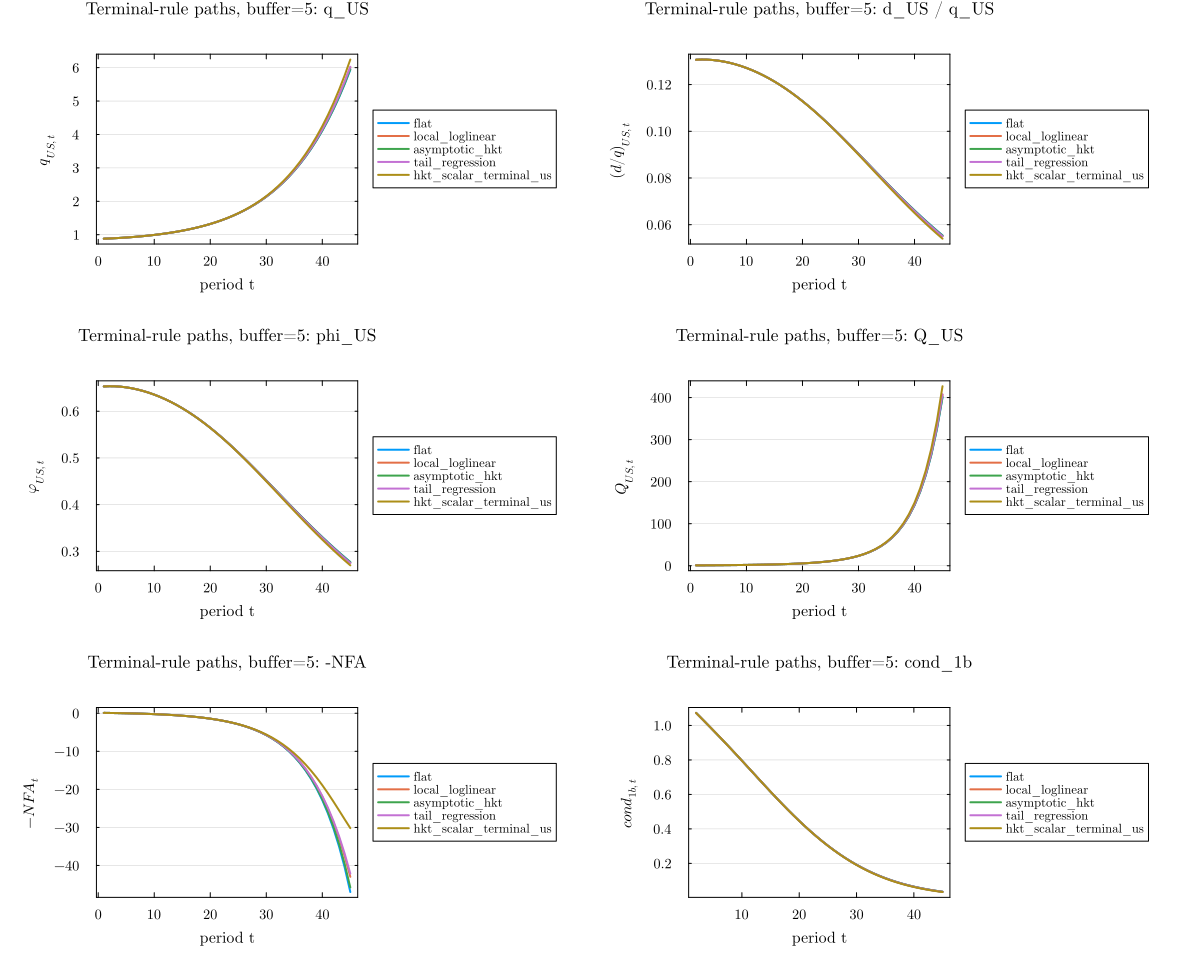

In [13]:
fig_terminal_paths = plot_path_grid(terminal_plot_cases;
    title_prefix="Terminal-rule paths, buffer=$TERMINAL_PLOT_BUFFER",
    T0=TERMINAL_T_REPORT,
    filename="terminal_rule_sensitivity_paths.png",
    label_fn=rule_label)
fig_terminal_paths


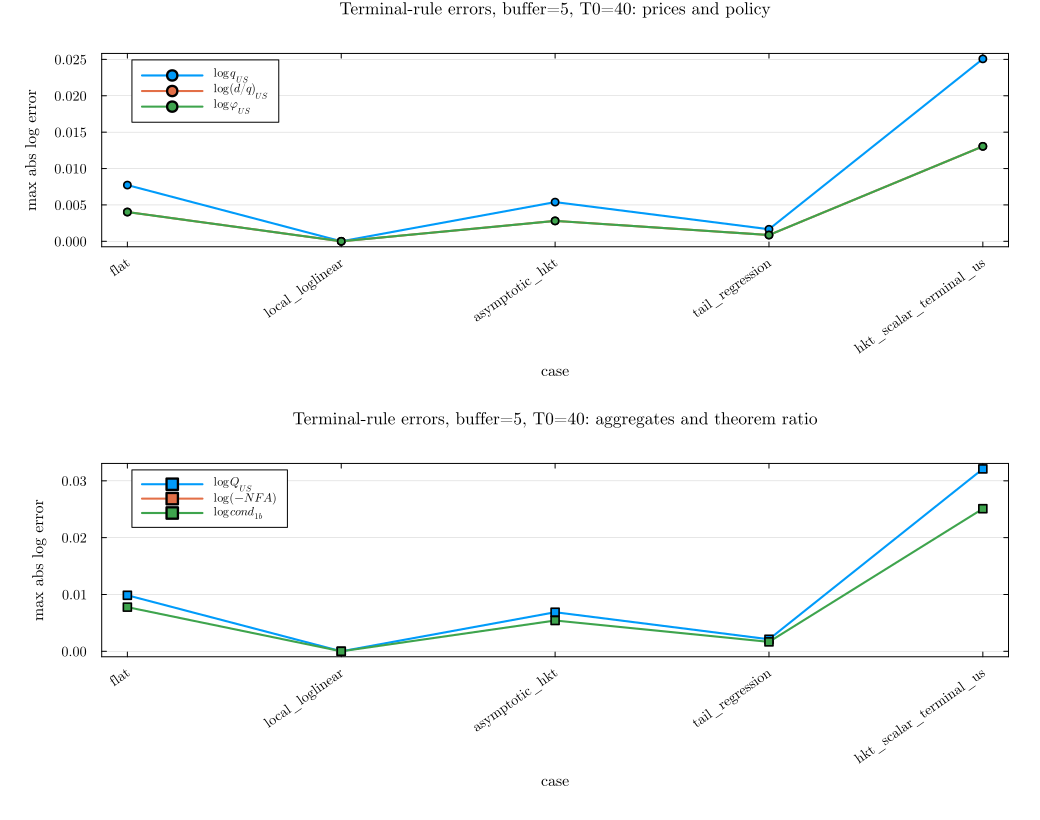

In [14]:
terminal_plot_T0 = maximum(T0_GRID)
terminal_error_plot_rows = filter(r -> r.n_buffer == TERMINAL_PLOT_BUFFER &&
                                       r.T0 == terminal_plot_T0 && r.status == "ok",
                                  terminal_rows)
fig_terminal_errors = plot_error_grid(terminal_error_plot_rows;
    title_prefix="Terminal-rule errors, buffer=$TERMINAL_PLOT_BUFFER, T0=$terminal_plot_T0",
    filename="terminal_rule_sensitivity_errors.png",
    label_fn=row_rule_label)
fig_terminal_errors


## 6. Output Files And Reading The Evidence

The merged notebook writes all current tail-analysis artifacts to `Two_country_production/outputs_v43/approximation_error_in_tails/` by default. Set `TAIL_ANALYSIS_OUTDIR` only for temporary smoke runs.

Main files:

- `horizon_buffer_case_summary.csv`
- `horizon_buffer_invariance.csv`
- `horizon_buffer_paths.csv`
- `horizon_buffer_paths.png`
- `horizon_buffer_invariance_errors.png`
- `hkt_scalar_prerequisite_summary.csv`
- `hkt_scalar_prerequisite_tail_rows.csv`
- `hkt_scalar_prerequisite_diagnostics.png`
- `terminal_rule_case_summary.csv`
- `terminal_rule_sensitivity.csv`
- `terminal_rule_sensitivity_paths.csv`
- `terminal_rule_sensitivity_paths.png`
- `terminal_rule_sensitivity_errors.png`

Interpretation guide: horizon/buffer invariance is a numerical-tail robustness check under the local-loglinear closure. Terminal-rule sensitivity then asks whether terminal closure choices, including the theoretically motivated HKT scalar U.S.-dominant successor, materially change reported-window objects. The HKT scalar prerequisite tables should be read first; they certify whether the local-loglinear extended tail has moved into the asymptotic environment required by the scalar successor.


In [15]:
println("Saved output files in:")
println("  ", OUTDIR)
for f in sort(readdir(OUTDIR))
    println("  ", joinpath(OUTDIR, f))
end


Saved output files in:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails/hkt_scalar_prerequisite_diagnostics.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails/hkt_scalar_prerequisite_summary.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails/hkt_scalar_prerequisite_tail_rows.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails/horizon_buffer_bubble_share_diagnostics.csv
  /U